In [9]:
import networkx as nx
import pickle
import copy
import matplotlib.pyplot as plt
from epidemic_simulation.sir_simulation import fast_SIR
from epidemic_simulation.helpers import *
from sample.helpers import *
from sample.sampling_trees_MH import TreeSamplerMH
from sample.sampling_trees import feasible_tree

In [5]:
#Loading our example of verification test
with open('data/graphs/verification_test_graph.pickle', mode='rb') as f:
    G = pickle.load(f)

beta = 0.4
fast_SIR(G, [0], beta)

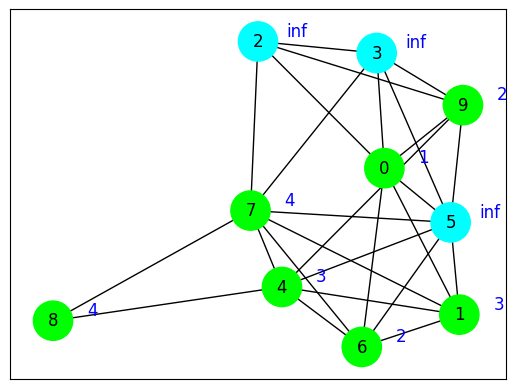

In [ ]:
#Visualization of the graph with their respectives infection times
color_state_map = {'recovered': 'lime', 'susceptible': 'cyan'}
node_color = [color_state_map[node[1]['status']] for node in G.nodes(data=True)]

infection_times = nx.get_node_attributes(G, "inf_time")
pos = nx.spring_layout(G, seed = 0)
state_pos = {n: (x + 0.14, y + 0.05) for n, (x,y) in pos.items()}

nx.draw_networkx(G,
                pos,
                node_size = 800,
                node_color = node_color,)

nx.draw_networkx_labels(G, state_pos, labels= infection_times, font_color='blue')
plt.show()

In [7]:
#Making a copy with the real infection times
G_real = copy.deepcopy(G)

#Selecting a fraction of nodes that will not be observed.
p_excluded = 0.4
excluded, infected_nodes = excludeInfTime(G, p_excluded)

#Deleting nodes that we known were not infected from the graph.
delete_susceptibles(G)

T_initial = feasible_tree(G, infected_nodes, flag=1)

In [8]:
if None in T_initial:
    print("Feasible tree not found!")

else:
    print(T_initial)

    samplings_number = 100000

    #Initialize class
    sampler = TreeSamplerMH(G, T_initial, infected_nodes,flag=1)

    #Run
    sampling = sampler.run(n_iterations=samplings_number)
    print(f"Real infection times: {nx.get_node_attributes(G_real, "inf_time")}")
    print("--------------------------------------------------------------------------------------------")
    print(f"Frequency of nodes: {nodes_proportion(G, sampling)}")

[[0], [4, 1, 0], [6, 0], [9, 0]]


Sampling trees: 100%|██████████| 100000/100000 [00:29<00:00, 3425.67it/s]


Final Acceptance Rate: 51.74%
Real infection times: {0: 1, 1: 3, 2: inf, 3: inf, 4: 3, 5: inf, 6: 2, 7: 4, 8: 4, 9: 2}
--------------------------------------------------------------------------------------------
Frequency of nodes: {0: 1.0, 1: 0.4150949633866142, 2: 0.4628493974907847, 4: 1.0, 6: 1.0, 7: 0.9998842917830636, 8: 0.0009917847165975173, 9: 1.0}


### Plots (visualizing results)